### SONG LANGUAGE PREDICTION

##### Vaidehi Dave - 1AUA23BCS198

In [16]:
import tensorflow as tf
import numpy as np
import librosa #Librosa — an audio analysis library. This is the one that actually reads audio files and extracts MFCCs from them.
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from google.colab import drive

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: []


In [17]:
drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/Deep Learning Dataset'
LANGUAGES    = ['Hindi', 'English', 'Japanese']
CHUNK_SECS   = 5
SAMPLE_RATE  = 22050 #It means 22050 audio samples are captured per second.

#Loops through each language, builds the full folder path, lists all files inside it and prints the count
for lang in LANGUAGES:
    folder = os.path.join(DATASET_PATH, lang)
    files  = os.listdir(folder)
    print(f"{lang}: {len(files)} chunks")

Mounted at /content/drive
Hindi: 1052 chunks
English: 875 chunks
Japanese: 1085 chunks


In [18]:
file_paths = []
labels     = []

for lang in LANGUAGES:
    folder = os.path.join(DATASET_PATH, lang)
    for file in sorted(os.listdir(folder)):
        if file.endswith('.wav') or file.endswith('.mp3'):
            file_paths.append(os.path.join(folder, file))
            labels.append(lang)

le = LabelEncoder()
y  = le.fit_transform(labels)

print(f"Total files : {len(file_paths)}")
print(f"Label map   : {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"Samples per class: {np.bincount(y)}")

Total files : 3012
Label map   : {np.str_('English'): np.int64(0), np.str_('Hindi'): np.int64(1), np.str_('Japanese'): np.int64(2)}
Samples per class: [ 875 1052 1085]


In [19]:
def extract_features(file_path):
    # Load 5 seconds of audio
    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=CHUNK_SECS)

    # Pad if audio is shorter than 5 seconds
    expected_len = SAMPLE_RATE * CHUNK_SECS
    if len(audio) < expected_len:
        audio = np.pad(audio, (0, expected_len - len(audio)))

    # Extract MFCCs and their derivatives
    mfcc   = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    # Mean + std of each → fixed size vector per chunk
    features = np.concatenate([
        np.mean(mfcc,   axis=1), np.std(mfcc,   axis=1),   # 80 captures vocal/phoneme characteristics
        np.mean(delta,  axis=1), np.std(delta,  axis=1),   # 80 how fast MFCCs are changing
        np.mean(delta2, axis=1), np.std(delta2, axis=1),   # 80  acceleration of that change
    ])

    return features  # shape: (240,)

# Quick test
sample = extract_features(file_paths[0])
print("Feature vector shape:", sample.shape)  # should be (240,)

Feature vector shape: (240,)


In [6]:
# FEATURES_PATH = '/content/drive/MyDrive/Deep Learning Dataset/features'
# os.makedirs(FEATURES_PATH, exist_ok=True)

# X = []

# for i, fp in enumerate(file_paths):
#     try:
#         feat = extract_features(fp)
#         X.append(feat)
#     except Exception as e:
#         print(f"Skipped {fp}: {e}")
#         X.append(np.zeros(240))

#     if i % 100 == 0:
#         print(f"  {i}/{len(file_paths)} done...")

# X = np.array(X)

# # Save to Drive — next time just load these directly
# np.save(f"{FEATURES_PATH}/X.npy", X)
# np.save(f"{FEATURES_PATH}/y.npy", y)

# print(f"\nDone!")
# print(f"X shape : {X.shape}")   # (1440, 240)
# print(f"y shape : {y.shape}")   # (1440,)
# print(f"Saved to: {FEATURES_PATH}")

In [20]:
FEATURES_PATH = '/content/drive/MyDrive/Deep Learning Dataset/features'
X = np.load(f"{FEATURES_PATH}/X.npy")
y = np.load(f"{FEATURES_PATH}/y.npy")
print("X:", X.shape, "y:", y.shape)

X: (3012, 240) y: (3012,)


In [21]:
from sklearn.model_selection import train_test_split

# Step 1 — separate test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # equal chunks from each language in every split
)

# Step 2 — separate val set from remaining train (10%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("Train:", X_train.shape, "→ labels:", np.bincount(y_train))
print("Val  :", X_val.shape,   "→ labels:", np.bincount(y_val))
print("Test :", X_test.shape,  "→ labels:", np.bincount(y_test))

Train: (2168, 240) → labels: [630 757 781]
Val  : (241, 240) → labels: [70 84 87]
Test : (603, 240) → labels: [175 211 217]


In [22]:
from sklearn.preprocessing import StandardScaler

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # learn mean & std from train only
X_val   = scaler.transform(X_val)         # apply same scale
X_test  = scaler.transform(X_test)        # apply same scale

print("Mean (should be ~0):", X_train.mean().round(4))
print("Std  (should be ~1):", X_train.std().round(4))


Mean (should be ~0): -0.0
Std  (should be ~1): 1.0


### MLP Model(Baseline - MFCC + Deltas)

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_mlp(input_shape=240, num_classes=3):
    model = Sequential([

        # Input + stabilize
        BatchNormalization(input_shape=(input_shape,)),

        # Hidden layer 1
        Dense(256, activation='relu'),
        Dropout(0.3),

        # Hidden layer 2
        Dense(128, activation='relu'),
        Dropout(0.3),

        # Hidden layer 3
        Dense(64, activation='relu'),

        # Output
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_mlp()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_3           │ (None, 240)            │           960 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        61,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,003 (406.26 KB)

 Trainable params: 103,523 (404.39 KB)

 Non-trainable params: 480 (1.88 KB)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

SAVE_PATH = '/content/drive/MyDrive/Deep Learning Dataset/models'
import os
os.makedirs(SAVE_PATH, exist_ok=True)

callbacks = [
    # Stop training if val_loss doesn't improve for 10 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Save best model to Drive automatically
    ModelCheckpoint(
        filepath=f'{SAVE_PATH}/mlp_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
56/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4615 - loss: 1.0615
Epoch 1: val_loss improved from None to 0.66103, saving model to /content/drive/MyDrive/Deep Learning Dataset/models/mlp_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Deep Learning Dataset/models/mlp_best.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5351 - loss: 0.9610 - val_accuracy: 0.7427 - val_loss: 0.6610
Epoch 2/50
58/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6900 - loss: 0.7197
Epoch 2: val_loss improved from 0.66103 to 0.45012, saving model to /content/drive/MyDrive/Deep Learning Dataset/models/mlp_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Deep Learning Dataset/models/mlp_best.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7251 - loss: 0.6542 - val_accuracy: 0.8506 - val_loss: 0.4501
Epoch 3/50
66/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8205 - loss: 0.4733
Epoch 3: val_loss improved from 0.45012 to 0.3

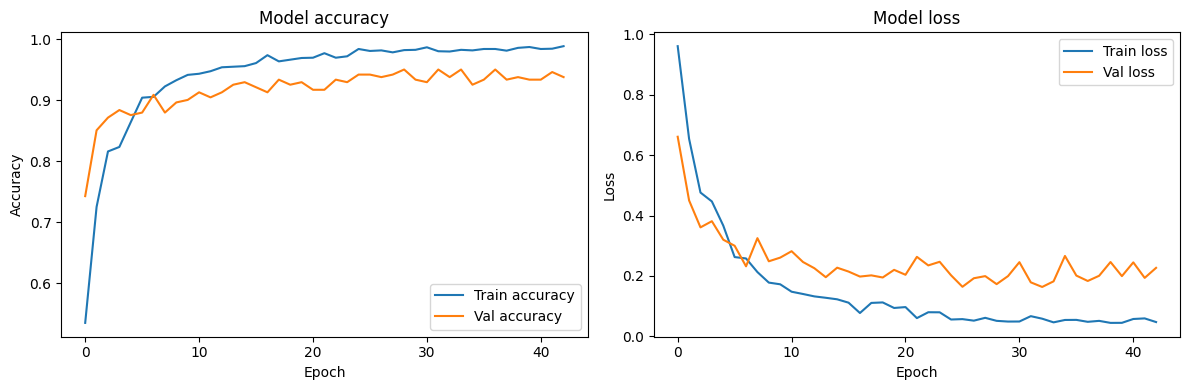

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val accuracy')
axes[0].set_title('Model accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train loss')
axes[1].plot(history.history['val_loss'], label='Val loss')
axes[1].set_title('Model loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/mlp_training_curves.png', dpi=150)
plt.show()

Test accuracy : 91.04%
Test loss     : 0.3525
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Classification Report:
              precision    recall  f1-score   support

       Hindi       0.92      0.89      0.91       175
     English       0.89      0.91      0.90       211
    Japanese       0.92      0.92      0.92       217

    accuracy                           0.91       603
   macro avg       0.91      0.91      0.91       603
weighted avg       0.91      0.91      0.91       603



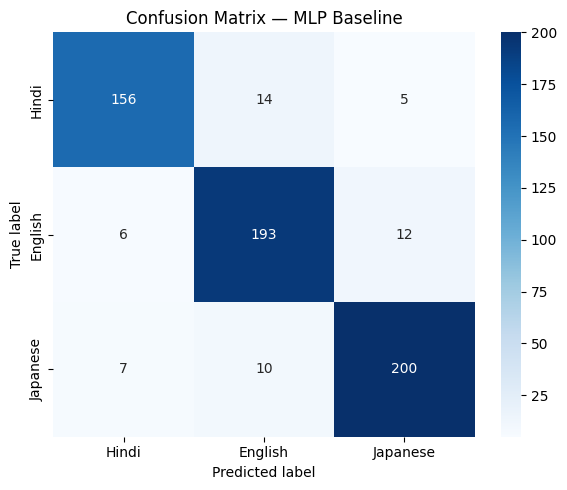

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy : {test_acc*100:.2f}%")
print(f"Test loss     : {test_loss:.4f}")

# Predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=LANGUAGES))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LANGUAGES, yticklabels=LANGUAGES)
plt.title('Confusion Matrix — MLP Baseline')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/mlp_confusion_matrix.png', dpi=150)
plt.show()

### CNN - Mel Spectogram

In [27]:
# extract mel spectrograms (n_mels=64, no per-sample norm) ───────
import numpy as np
import librosa
import os
from pathlib import Path

DATASET_PATH  = '/content/drive/MyDrive/Deep Learning Dataset/'
FEATURES_PATH = DATASET_PATH + 'features/'

label_map   = {'English': 0, 'Hindi': 1, 'Japanese': 2}
audio_files = []
labels      = []

for lang, idx in label_map.items():
    folder = os.path.join(DATASET_PATH, lang)
    files  = sorted(Path(folder).glob('*.wav'))
    for f in files:
        audio_files.append(str(f))
        labels.append(idx)

print(f"Total files found: {len(audio_files)}")
print(f"Expected: 3012")

Total files found: 3012
Expected: 3012


In [29]:
# extract mel spectorgrams
X_mel_new = []

for i, fpath in enumerate(audio_files):
    audio, sr = librosa.load(fpath, sr=22050, duration=5.0)

    # Pad if shorter than 5 sec
    target_len = 22050 * 5
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))

    # Fixed: n_mels=64, only power_to_db (no per-sample norm)
    mel    = librosa.feature.melspectrogram(
                 y=audio, sr=sr,
                 n_fft=2048, hop_length=512, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=np.max)  # (64, 216)
    mel_db = mel_db[..., np.newaxis]               # (64, 216, 1)

    X_mel_new.append(mel_db)

    if (i+1) % 300 == 0:
        print(f"  {i+1}/{len(audio_files)} done...")

X_mel_new = np.array(X_mel_new, dtype=np.float32)
y_new     = np.array(labels, dtype=np.int32)

print(f"\nX_mel_new shape : {X_mel_new.shape}")  # expect (3012, 64, 216, 1)
print(f"y_new shape     : {y_new.shape}")

  300/3012 done...
  600/3012 done...
  900/3012 done...
  1200/3012 done...
  1500/3012 done...
  1800/3012 done...
  2100/3012 done...
  2400/3012 done...
  2700/3012 done...
  3000/3012 done...

X_mel_new shape : (3012, 64, 216, 1)
y_new shape     : (3012,)


In [30]:
# Split + global normalize ──────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_temp, X_mel_test,  y_temp, y_test  = train_test_split(
    X_mel_new, y_new, test_size=0.20, stratify=y_new, random_state=42)
X_mel_train, X_mel_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.10, stratify=y_temp, random_state=42)

# Global norm using train stats only
mean = X_mel_train.mean()
std  = X_mel_train.std()

X_mel_train = (X_mel_train - mean) / std
X_mel_val   = (X_mel_val   - mean) / std
X_mel_test  = (X_mel_test  - mean) / std

print(f"Train : {X_mel_train.shape}")
print(f"Val   : {X_mel_val.shape}")
print(f"Test  : {X_mel_test.shape}")
print(f"Norm  — mean: {X_mel_train.mean():.4f}, std: {X_mel_train.std():.4f}")

Train : (2168, 64, 216, 1)
Val   : (241, 64, 216, 1)
Test  : (603, 64, 216, 1)
Norm  — mean: -0.0000, std: 1.0000


In [21]:
# Build + train simplified CNN ──────────────────────────────────────
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

def build_cnn(input_shape=(64, 216, 1), num_classes=3):
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(32, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.0003),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn()
cnn_model.summary()

# Class weights
weights      = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))
print("\nClass weights:", class_weights)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(MODELS_PATH + 'cnn_best_v2.keras',
                    monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1)
]

# Train
history_cnn = cnn_model.fit(
    X_mel_train, y_train,
    validation_data=(X_mel_val, y_val),
    epochs=30,
    batch_size=16,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 214, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 107, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 105, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 52, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 46592)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     2,981,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,963 (11.45 MB)

 Trainable params: 3,000,963 (11.45 MB)

 Non-trainable params: 0 (0.00 B)


Class weights: {0: np.float64(1.1470899470899472), 1: np.float64(0.9546455306032585), 2: np.float64(0.9253094323516858)}
Epoch 1/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.4084 - loss: 1.1904
Epoch 1: val_loss improved from None to 0.91860, saving model to /content/drive/MyDrive/Deep Learning Dataset/models/cnn_best_v2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Deep Learning Dataset/models/cnn_best_v2.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 48s 327ms/step - accuracy: 0.4594 - loss: 1.0545 - val_accuracy: 0.6473 - val_loss: 0.9186 - learning_rate: 3.0000e-04
Epoch 2/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.5734 - loss: 0.9077
Epoch 2: val_loss improved from 0.91860 to 0.71147, saving model to /content/drive/MyDrive/Deep Learning Dataset/models/cnn_best_v2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Deep Learning Dataset/models/cnn_best_v2.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 78s 303ms/step - accuracy: 0.5913 - loss: 


CNN v2 — Test Loss: 0.4883 | Test Accuracy: 80.76%
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 342ms/step

               precision    recall  f1-score   support

     English       0.76      0.79      0.77       175
       Hindi       0.83      0.79      0.81       211
    Japanese       0.83      0.83      0.83       217

    accuracy                           0.81       603
   macro avg       0.81      0.81      0.81       603
weighted avg       0.81      0.81      0.81       603



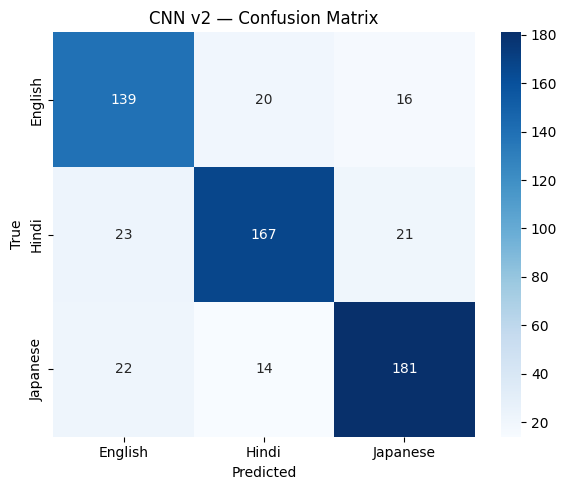

In [22]:
# Evaluate ──────────────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

test_loss, test_acc = cnn_model.evaluate(X_mel_test, y_test, verbose=0)
print(f"\nCNN v2 — Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc*100:.2f}%")

y_pred = np.argmax(cnn_model.predict(X_mel_test), axis=1)
print("\n", classification_report(y_test, y_pred,
      target_names=['English', 'Hindi', 'Japanese']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['English','Hindi','Japanese'],
            yticklabels=['English','Hindi','Japanese'])
plt.title('CNN v2 — Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

### 3 channels in CNN - Mel+MFCC+Delta

In [5]:
import numpy as np
import librosa
import os
from pathlib import Path

DATASET_PATH = '/content/drive/MyDrive/Deep Learning Dataset/'

label_map = {'English': 0, 'Hindi': 1, 'Japanese': 2}
audio_files, labels = [], []

for lang, idx in label_map.items():
    folder = os.path.join(DATASET_PATH, lang)
    files = sorted(Path(folder).glob('*.wav'))
    for f in files:
        audio_files.append(str(f))
        labels.append(idx)

print("Total files:", len(audio_files))


#  FEATURE EXTRACTION
X = []

for i, fpath in enumerate(audio_files):
    audio, sr = librosa.load(fpath, sr=22050, duration=5.0)

    target_len = 22050 * 5
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))

    # --- MEL ---
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_fft=2048, hop_length=512, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # --- MFCC ---
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

    # Match time dimension
    mfcc = librosa.util.fix_length(mfcc, size=mel_db.shape[1], axis=1)

    # Pad height (40 → 64)
    if mfcc.shape[0] < 64:
        mfcc = np.pad(mfcc, ((0, 64 - mfcc.shape[0]), (0, 0)))

    # --- DELTA ---
    delta = librosa.feature.delta(mfcc)

    # --- STACK (3 channels) ---
    combined = np.stack([mel_db, mfcc, delta], axis=-1)  # (64, 216, 3)

    X.append(combined)

    if (i+1) % 300 == 0:
        print(f"{i+1}/{len(audio_files)} processed")

X = np.array(X, dtype=np.float32)
y = np.array(labels, dtype=np.int32)

print("X shape:", X.shape)  # (3012, 64, 216, 3)

Total files: 3012
300/3012 processed
600/3012 processed
900/3012 processed
1200/3012 processed
1500/3012 processed
1800/3012 processed
2100/3012 processed
2400/3012 processed
2700/3012 processed
3000/3012 processed
X shape: (3012, 64, 216, 3)


In [31]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.10, stratify=y_temp, random_state=42)

# GLOBAL NORMALIZATION
mean = X_train.mean()
std  = X_train.std()

X_train = (X_train - mean) / std
X_val   = (X_val - mean) / std
X_test  = (X_test - mean) / std

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

Train: (2168, 240)
Val  : (241, 240)
Test : (603, 240)


In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D,
                                     GlobalAveragePooling2D,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam

def build_cnn(input_shape=(64, 216, 3), num_classes=3):
    model = Sequential([

        Input(shape=input_shape),

        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        GlobalAveragePooling2D(),

        Dense(64, activation='relu'),
        Dropout(0.5),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0003),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_cnn()
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 216, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 216, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 108, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 108, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 108, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 54, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 27, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,595 (400.76 KB)

 Trainable params: 102,147 (399.01 KB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

# Class weights
weights = compute_class_weight('balanced',
                               classes=np.unique(y_train),
                               y=y_train)
class_weights = dict(enumerate(weights))

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(patience=3, factor=0.5, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 94s 662ms/step - accuracy: 0.5401 - loss: 0.9538 - val_accuracy: 0.5187 - val_loss: 1.0052 - learning_rate: 3.0000e-04
Epoch 2/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 144s 681ms/step - accuracy: 0.6591 - loss: 0.7871 - val_accuracy: 0.4896 - val_loss: 0.9659 - learning_rate: 3.0000e-04
Epoch 3/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 139s 655ms/step - accuracy: 0.7177 - loss: 0.6889 - val_accuracy: 0.7593 - val_loss: 0.6518 - learning_rate: 3.0000e-04
Epoch 4/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 146s 687ms/step - accuracy: 0.7528 - loss: 0.6276 - val_accuracy: 0.8506 - val_loss: 0.5282 - learning_rate: 3.0000e-04
Epoch 5/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 145s 709ms/step - accuracy: 0.7837 - loss: 0.5678 - val_accuracy: 0.7427 - val_loss: 0.5709 - learning_rate: 3.0000e-04
Epoch 6/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 95s 703ms/step - accuracy: 0.8109 - loss: 0.5026 - val_accuracy: 0.8838 - val_loss: 0.3535 - learning_rate: 3.0000e-04
Epoch 7/30
136/136 ━━━━━━━━━━━━━━━━━━━━ 92


Test Accuracy: 93.53%
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 263ms/step

               precision    recall  f1-score   support

     English       0.97      0.91      0.94       175
       Hindi       0.91      0.95      0.93       211
    Japanese       0.94      0.94      0.94       217

    accuracy                           0.94       603
   macro avg       0.94      0.93      0.94       603
weighted avg       0.94      0.94      0.94       603



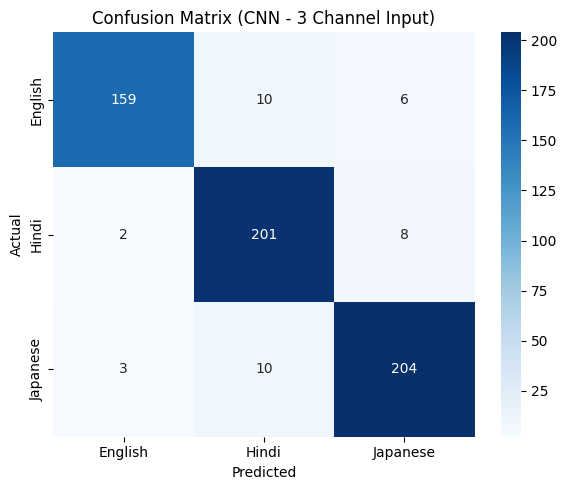

In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Test Accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# Predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

# Classification Report
print("\n", classification_report(
    y_test, y_pred,
    target_names=['English', 'Hindi', 'Japanese']
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['English', 'Hindi', 'Japanese'],
            yticklabels=['English', 'Hindi', 'Japanese'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (CNN - 3 Channel Input)')
plt.tight_layout()
plt.show()